# SkinSight AI — 02 · Extraction de features & PCA

Pipeline : Image → MobileNetV2 (1280D) + DenseNet121 (1024D) + InceptionV3 (2048D) → Concat (4352D) → PCA → 512D

## 0. Imports & configuration

In [1]:
import os, joblib
import numpy as np
import matplotlib.pyplot as plt
import psutil
import warnings
warnings.filterwarnings('ignore')

BASE_DIR  = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_DIR = os.path.join(BASE_DIR, 'models')
DATA_DIR  = os.path.join(BASE_DIR, 'data')

CLASSES = ['saine', 'acne_inflammatoire', 'acne_non_inflammatoire', 'rosacee', 'hyperpigmentation']
COLORS  = ['#C07A5A', '#8B6A8B', '#D4A896', '#7A9E7E', '#B8956A']

ram = psutil.virtual_memory()
print(f'BASE_DIR       : {BASE_DIR}')
print(f'RAM disponible : {ram.available/1e9:.1f} GB / {ram.total/1e9:.1f} GB ({ram.percent}% utilise)')

BASE_DIR       : c:\Users\nasri\OneDrive\Desktop\Projects\SkinSightAI
RAM disponible : 2.5 GB / 14.9 GB (83.0% utilise)


## 1. Chargement du PCA sauvegarde

In [2]:
pca = joblib.load(os.path.join(MODEL_DIR, 'pca_512.pkl'))
print(f'PCA charge avec succes')
print(f'  Dimensions entree  : {pca.n_features_in_}')
print(f'  Composantes        : {pca.n_components_}')
print(f'  Variance expliquee : {sum(pca.explained_variance_ratio_)*100:.2f}%')

PCA charge avec succes
  Dimensions entree  : 4352
  Composantes        : 512
  Variance expliquee : 88.69%


## 2. Courbe de variance expliquee

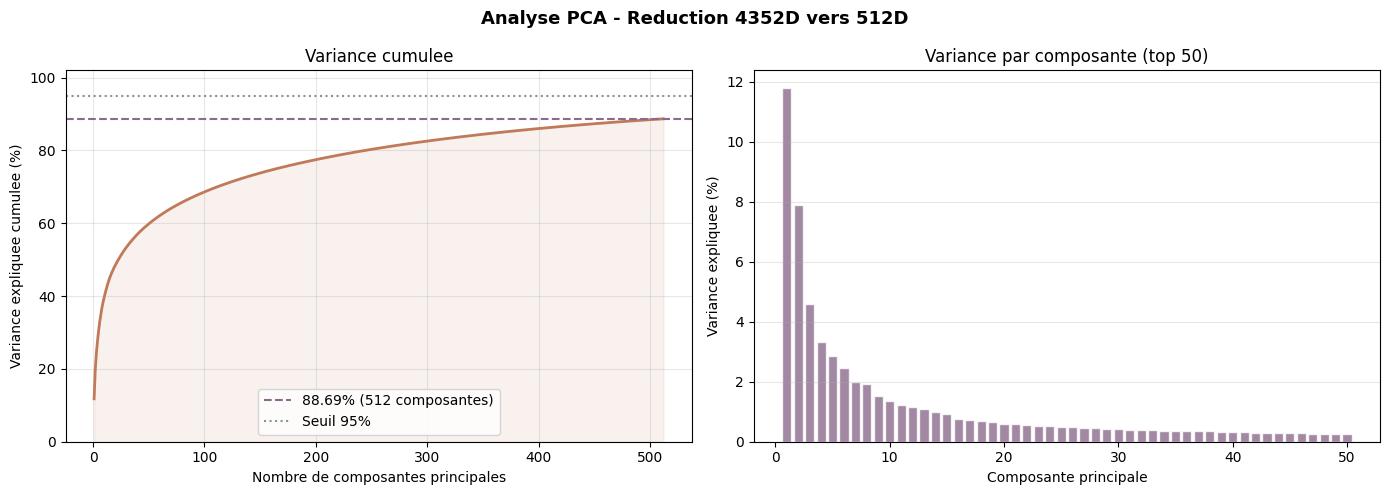

In [3]:
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Analyse PCA - Reduction 4352D vers 512D', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(range(1, len(cumvar)+1), cumvar, color='#C07A5A', linewidth=2)
ax.axhline(88.69, color='#8B6A8B', linestyle='--', linewidth=1.5, label='88.69% (512 composantes)')
ax.axhline(95, color='#7A9E7E', linestyle=':', linewidth=1.5, label='Seuil 95%')
ax.fill_between(range(1, len(cumvar)+1), cumvar, alpha=0.1, color='#C07A5A')
ax.set_xlabel('Nombre de composantes principales')
ax.set_ylabel('Variance expliquee cumulee (%)')
ax.set_title('Variance cumulee')
ax.legend(); ax.grid(alpha=0.3); ax.set_ylim(0, 102)

ax2 = axes[1]
top_n = 50
ax2.bar(range(1, top_n+1), pca.explained_variance_ratio_[:top_n]*100, color='#8B6A8B', alpha=0.8, edgecolor='white')
ax2.set_xlabel('Composante principale')
ax2.set_ylabel('Variance expliquee (%)')
ax2.set_title(f'Variance par composante (top {top_n})')
ax2.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_02_pca_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Chargement des features extraites

In [6]:
# Les .npy sont dans models/ et les labels aussi
X_train = np.load(os.path.join(MODEL_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(MODEL_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(MODEL_DIR, 'X_test.npy'))

y_train = np.load(os.path.join(MODEL_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(MODEL_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(MODEL_DIR, 'y_test.npy'))

print(f'X_train : {X_train.shape}  |  y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}    |  y_val   : {y_val.shape}')
print(f'X_test  : {X_test.shape}   |  y_test  : {y_test.shape}')

X_train : (5000, 512)  |  y_train : (5000,)
X_val   : (588, 512)    |  y_val   : (588,)
X_test  : (591, 512)   |  y_test  : (591,)


## 4. Visualisation t-SNE des features

Calcul t-SNE sur 300 points... (1-2 min)
t-SNE termine !


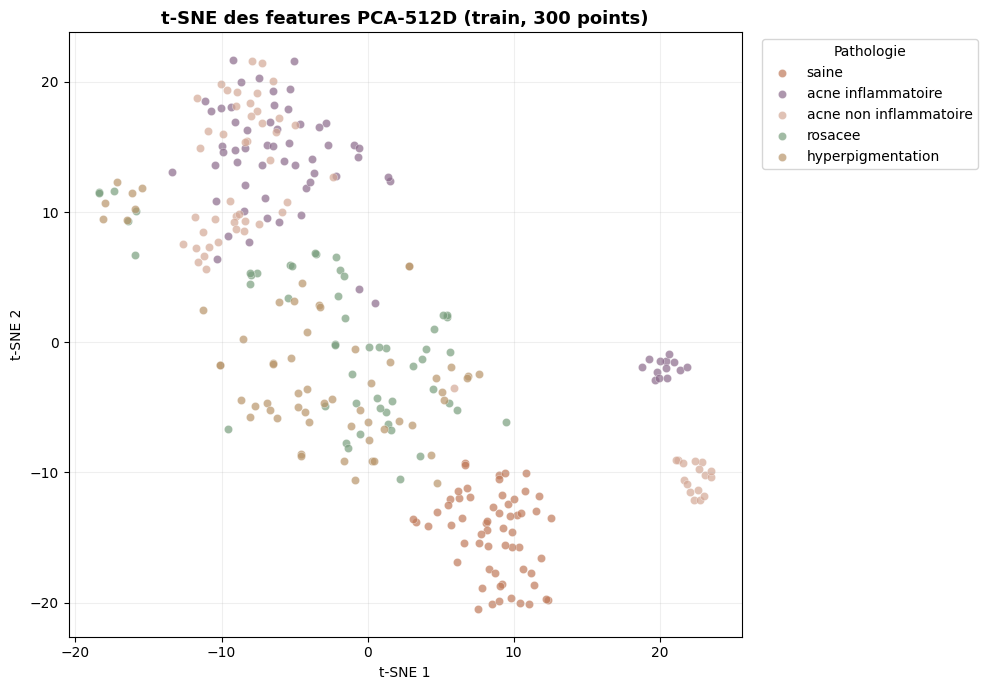

In [7]:
from sklearn.manifold import TSNE

N_SAMPLE = 300
np.random.seed(42)
idx  = np.random.choice(len(X_train), min(N_SAMPLE, len(X_train)), replace=False)
X_s  = X_train[idx]
y_s  = y_train[idx]

print(f'Calcul t-SNE sur {N_SAMPLE} points... (1-2 min)')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_2d = tsne.fit_transform(X_s)
print('t-SNE termine !')

fig, ax = plt.subplots(figsize=(10, 7))
for i, (cls, color) in enumerate(zip(CLASSES, COLORS)):
    mask = y_s == i
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color,
               label=cls.replace('_', ' '), alpha=0.7, s=35, edgecolors='white', linewidths=0.3)
ax.set_title('t-SNE des features PCA-512D (train, 300 points)', fontsize=13, fontweight='bold')
ax.legend(title='Pathologie', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2'); ax.grid(alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'notebooks', 'fig_02_tsne.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Architecture des extracteurs CNN

In [8]:
architectures = [
    {'modele': 'MobileNetV2', 'input': '224x224', 'output': '1280D', 'params': '3.4M',  'note': 'Leger, rapide'},
    {'modele': 'DenseNet121', 'input': '224x224', 'output': '1024D', 'params': '8.1M',  'note': 'Dense connections'},
    {'modele': 'InceptionV3', 'input': '299x299', 'output': '2048D', 'params': '23.8M', 'note': 'Multi-scale'},
]
print('Modele           Input     Output    Params    Caracteristique')
print('-' * 65)
for a in architectures:
    print(f"{a['modele']:<16} {a['input']:^10} {a['output']:^10} {a['params']:^10} {a['note']}")
print('-' * 65)
print(f"{'Concatenation':<16} {'—':^10} {'4352D':^10} {'—':^10} 1280+1024+2048")
print(f"{'PCA (512)':<16} {'4352D':^10} {'512D':^10} {'—':^10} 88.69% variance")
print()
print('Poids : ImageNet (transfer learning, pas de fine-tuning)')

Modele           Input     Output    Params    Caracteristique
-----------------------------------------------------------------
MobileNetV2       224x224     1280D       3.4M    Leger, rapide
DenseNet121       224x224     1024D       8.1M    Dense connections
InceptionV3       299x299     2048D      23.8M    Multi-scale
-----------------------------------------------------------------
Concatenation        —        4352D        —      1280+1024+2048
PCA (512)          4352D       512D        —      88.69% variance

Poids : ImageNet (transfer learning, pas de fine-tuning)


## Resume

| Etape | Detail |
|-------|--------|
| Entree | Image RGB quelconque |
| CNN x3 | MobileNetV2 + DenseNet121 + InceptionV3 (ImageNet, pooling avg) |
| Concatenation | 1280 + 1024 + 2048 = **4352 dimensions** |
| PCA | 4352D -> **512D** (88.69% de variance conservee) |
| Sortie | Vecteur 512D -> entree du classifieur LightGBM |